In [1]:
import os
import re
import emcee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import astropy.units as u
from astropy.io import fits
from scipy.signal import convolve
from scipy.optimize import minimize
from linetools.spectra.lsf import LSF

In [2]:
target_directory = Path().resolve()
dla_directories = sorted([d for d in os.listdir(target_directory) if d.startswith("G130M") or d.startswith("E140M")])
print(dla_directories)

['G130M_1291_LP4_1534.400_16101']


In [3]:
def parse_directory(dirname):

    Target = target_directory.name

    parts = dirname.split("_")

    Grating = parts[0]
    Cenwave = int(parts[1])
    T_exp = str(parts[3])
    PID = int(parts[4])

    if Grating.startswith("G"):
        
        Instrument = "COS"
        LP = parts[2]

        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": LP, 
            "Aperture": None, 
            "T_exp": T_exp, 
            "PID": PID, 
        }
        
    else:
        
        Instrument = "STIS"
        Aperture = parts[2]
        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": None, 
            "Aperture": Aperture, 
            "T_exp": T_exp, 
            "PID": PID, 
        }

records = [parse_directory(d) for d in dla_directories]
df = pd.DataFrame.from_records(records)
display(df)

,Target,Instrument,Grating,Cenwave,LP,Aperture,T_exp,PID
0,2dFS 3694,COS,G130M,1291,LP4,None,1534.400,16101


In [4]:
def Ly_alpha_profile(wave, logN, z):

    N = 10.0 ** logN
    lambda0 = 1215.67 * (1.0 + z)
    return 4.26e-20 * N / (6.04e-10 + (wave - lambda0) ** 2)

In [5]:
def model_spectrum(wave, continuum, logN_mw, logN_sys, z_mw, z_sys, lsf):
    
    tau = Ly_alpha_profile(wave, logN_mw, z_mw) + Ly_alpha_profile(wave, logN_sys, z_sys)

    model = continuum * np.exp(-tau)
    model = convolve(model, lsf['kernel'], mode = 'same') # LSF makes ~0.1 dex difference
    
    return model

In [6]:
def fit_hi_columns(df_spec, i, wave, flux, err, z_mw, z_sys, cont_windows, fit_windows):

    Grating = df_spec["Grating"].tolist()[i]
    if Grating.startswith("G"):
        lsf_obj = LSF(dict(name = df_spec["Instrument"].tolist()[i], grating = df_spec["Grating"].tolist()[i], life_position = str(df_spec["LP"].tolist()[i].lstrip("LP")), cen_wave = str(df_spec["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic')
    else:
        lsf_obj = LSF(dict(name = df_spec["Instrument"].tolist()[i], grating = df_spec["Grating"].tolist()[i], slit = str(df_spec["Aperture"].tolist()[i].lstrip("LP")), cen_wave = str(df_spec["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic')

    cont_mask = np.zeros_like(wave, dtype = bool)
    for bounds in cont_windows:
        cont_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    continuumfit = np.polyfit(wave[cont_mask], flux[cont_mask], 1) # Linear continuum
    cont = np.polyval(continuumfit, wave)

    flux_mask = np.zeros_like(wave, dtype = bool)
    for bounds in fit_windows:
        flux_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    masked_wave, masked_flux, masked_err = wave[flux_mask], flux[flux_mask], err[flux_mask]

    NHI_mw_array, NHI_sys_array = np.linspace(18.0, 22.5, 1000), np.linspace(18.0, 22.5, 1000)
    chi_squared_array = np.empty((NHI_mw_array.size, NHI_sys_array.size))

    for i, NHI_mw in enumerate(NHI_mw_array):
        for j, NHI_sys in enumerate(NHI_sys_array):
            dla = model_spectrum(wave, cont, NHI_mw, NHI_sys, z_mw, z_sys, lsf)
            res = (masked_flux - dla[flux_mask]) / masked_err
            chi_squared_array[i, j] = np.sum(res ** 2)

    idx_min = np.unravel_index(np.argmin(chi_squared_array), chi_squared_array.shape)
    best_mw, best_sys = NHI_mw_array[idx_min[0]], NHI_sys_array[idx_min[1]]
    best_model = model_spectrum(wave, cont, best_mw, best_sys, z_mw, z_sys, lsf)

    chi_squared_array_min = chi_squared_array[idx_min]
    good = chi_squared_array <= chi_squared_array_min + 2.3
    good_indices = np.where(good)
    good_mw_vals = NHI_mw_array[good_indices[0]]
    good_sys_vals = NHI_sys_array[good_indices[1]]
    
    err_mw = 0.5 * (np.max(good_mw_vals) - np.min(good_mw_vals))
    err_sys = 0.5 * (np.max(good_sys_vals) - np.min(good_sys_vals))

    return best_mw, err_mw, best_sys, err_sys, cont, best_model, chi_squared_array, lsf

In [ ]:
hdul = fits.open('/Users/billyli/Documents/float-for-morrow/SMC/2dFS 3694/G130M_1291_LP4_1534.400_16101/leeyac010_x1dsum.fits')
wave = np.concatenate(hdul[1].data['WAVELENGTH'])
flux = np.concatenate(hdul[1].data['FLUX'])
err  = np.concatenate(hdul[1].data['ERROR'])

sorted_indices = np.argsort(wave)
wave = wave[sorted_indices]
flux = flux[sorted_indices]
err = err[sorted_indices]

df_spec, i = df, 0
z_mw, z_sys = 0.0, 0.00053
cont_windows = [[1136, 1138], [1265, 1270]]
fit_windows = [[1180, 1187], [1201.5, 1206], [1208.5, 1210], [1221, 1238]]
best_mw, err_mw, best_sys, err_sys, cont, best_model, chi_squared_array, lsf = fit_hi_columns(df_spec, i, wave, flux, err, z_mw, z_sys, cont_windows, fit_windows)

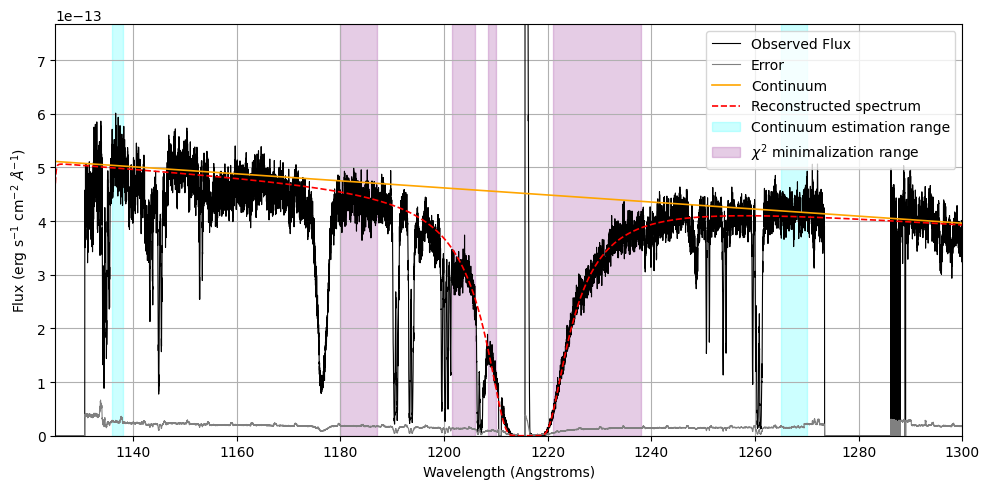

In [19]:
plt.figure(figsize = (10, 5))
plt.plot(wave, flux, label = 'Observed Flux', color = 'black', lw = 0.8)
plt.plot(wave, err, label = 'Error', color = 'grey', lw = 0.8)
plt.plot(wave, cont, label = 'Continuum', color = 'orange', lw = 1.2)
plt.plot(wave, best_model, label = 'Reconstructed spectrum', color = 'red', lw = 1.2, linestyle = '--')

y_max = np.max(cont) * 1.5

for i in range(len(cont_windows)):
    bounds = cont_windows[i]
    if i == 0:
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, label = 'Continuum estimation range', color = 'cyan')
    else: 
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, color = 'cyan')

for i in range(len(fit_windows)):
    bounds = fit_windows[i]
    if i == 0:
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, label = r'$\chi^2$ minimalization range', color = 'purple')
    else: 
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, color = 'purple')

plt.xlabel('Wavelength (Angstroms)')
plt.ylabel(r'Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')
plt.xlim(1125, 1300)
plt.ylim(0, y_max)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

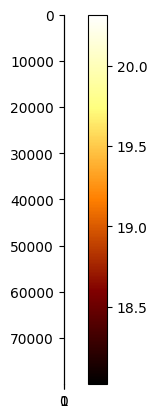

In [16]:
plt.imshow(chi_squared_array, cmap = 'afmhot', vmin = np.min(chi_squared_array), vmax = np.min(chi_squared_array) + 2.3)
plt.colorbar()

In [17]:
best_mw, err_mw, best_sys, err_sys

(np.float64(20.923217333562835),
 np.float64(0.011563401305254573),
 np.float64(20.718369970391862),
 np.float64(0.017027904644017156))

In [32]:
def fit_hi_columns_mcmc(df_spec, i, wave, flux, err, z_mw, z_sys, cont_windows, fit_windows):

    Grating = df_spec["Grating"].tolist()[i]
    if Grating.startswith("G"):
        lsf_obj = LSF(dict(name = df_spec["Instrument"].tolist()[i], grating = df_spec["Grating"].tolist()[i], life_position = str(df_spec["LP"].tolist()[i].lstrip("LP")), cen_wave = str(df_spec["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic')
    else:
        lsf_obj = LSF(dict(name = df_spec["Instrument"].tolist()[i], grating = df_spec["Grating"].tolist()[i], slit = str(df_spec["Aperture"].tolist()[i].lstrip("LP")), cen_wave = str(df_spec["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic')

    cont_mask = np.zeros_like(wave, dtype = bool)
    for bounds in cont_windows:
        cont_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    continuumfit = np.polyfit(wave[cont_mask], flux[cont_mask], 1) # Linear continuum
    cont = np.polyval(continuumfit, wave)

    flux_mask = np.zeros_like(wave, dtype = bool)
    for bounds in fit_windows:
        flux_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    masked_wave, masked_flux, masked_err, masked_cont = wave[flux_mask], flux[flux_mask], err[flux_mask], cont[flux_mask]

    def log_prob(x): # assuming Gaussian density, using https://emcee.readthedocs.io/en/stable/tutorials/quickstart/#quickstart

        logN_mw, logN_sys = x
        model = model_spectrum(masked_wave, masked_cont, logN_mw, logN_sys, z_mw, z_sys, lsf)
        res = (masked_flux - model) / masked_err
        likelihood = -0.5 * np.sum(res ** 2)

        if not (18.0 <= logN_mw <= 22.5 and 18.0 <= logN_sys <= 22.0):
            return -np.inf
        return likelihood

    ndim, nwalkers = 2, 100
    p0 = np.random.uniform(18.0, 22.5, size = (nwalkers, ndim)) # initial guess
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
    state = sampler.run_mcmc(p0, 100) # burn-in
    sampler.reset()
    sampler.run_mcmc(p0, 1000, progress = True);

    flat_samples = sampler.get_chain(flat = True)
    best_idx = np.argmax([log_prob(x) for x in flat_samples])
    best_mw, best_sys = flat_samples[best_idx]

    err_mw = 0.5 * (np.percentile(flat_samples[:, 0], 84) - np.percentile(flat_samples[:, 0], 16)) # estimate standard error by looking for the middle 68%
    err_sys = 0.5 * (np.percentile(flat_samples[:, 1], 84) - np.percentile(flat_samples[:, 1], 16))
    best_model = model_spectrum(wave, cont, best_mw, best_sys, z_mw, z_sys, lsf)

    return best_mw, err_mw, best_sys, err_sys, cont, best_model

In [ ]:
hdul = fits.open('/Users/billyli/Documents/float-for-morrow/SMC/2dFS 3694/G130M_1291_LP4_1534.400_16101/leeyac010_x1dsum.fits')
wave = np.concatenate(hdul[1].data['WAVELENGTH'])
flux = np.concatenate(hdul[1].data['FLUX'])
err  = np.concatenate(hdul[1].data['ERROR'])

sorted_indices = np.argsort(wave)
wave = wave[sorted_indices]
flux = flux[sorted_indices]
err = err[sorted_indices]

df_spec, i = df, 0
z_mw, z_sys = 0.0, 0.00053
cont_windows = [[1136, 1138], [1265, 1270]]
fit_windows = [[1180, 1187], [1201.5, 1206], [1208.5, 1210], [1221, 1238]]
best_mw, err_mw, best_sys, err_sys, cont, best_model = fit_hi_columns_mcmc(df_spec, i, wave, flux, err, z_mw, z_sys, cont_windows, fit_windows)

100%|███████████████████████████████████████| 1000/1000 [00:41<00:00, 23.83it/s]
